# P1 FCMAE encoder training across folds

This notebook combines the `fcmae_p1_history_fold*.csv` run histories with the independent frozen-encoder feature audit:

1. **Fold dashboards** — training/validation loss, feature standard deviation, and learning rate for every fold.
2. **Cross-fold summary** — convergence consistency, best-checkpoint timing, improvement, and end-of-run behavior.
3. **Feature-audit summary** — pinned-initialization versus P1 evidence for local anatomy, cross-view retrieval, and representation diversity.

The best checkpoint is defined by the minimum `validation_loss`, matching the P1 training code. `feature_std` is treated as a representation-collapse diagnostic; the training contract requires it to remain above `1e-6`. Train and validation loss are shown together, but their absolute difference is not labelled as an overfitting gap because P1 training uses stochastic masking and augmentation.

## 1. Load and validate all fold histories

The path search works when the notebook is launched from the repository root or from a directory inside it. No result files are modified.

In [12]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

HISTORY_PATTERN = "fcmae_p1_history_fold*.csv"
ROLLING_WINDOW = 9
FEATURE_STD_MIN = 1e-6
REQUIRED_COLUMNS = {"epoch", "train_loss", "validation_loss", "feature_std", "lr"}

def find_project_root(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / "TestProject" / "models" / "foundation_stage2_v1").is_dir():
            return candidate / "TestProject"
        if (candidate / "models" / "foundation_stage2_v1").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate models/foundation_stage2_v1 from the current directory.")

PROJECT_ROOT = find_project_root(Path.cwd())
HISTORY_DIR = PROJECT_ROOT / "models" / "foundation_stage2_v1"
history_files = sorted(HISTORY_DIR.glob(HISTORY_PATTERN))
if not history_files:
    raise FileNotFoundError(f"No histories matched {HISTORY_DIR / HISTORY_PATTERN}")

frames = []
for path in history_files:
    match = re.search(r"fold(\d+)", path.stem)
    if match is None:
        raise ValueError(f"Cannot infer fold number from {path.name}")
    frame = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")
    frame = frame.copy()
    frame[list(REQUIRED_COLUMNS)] = frame[list(REQUIRED_COLUMNS)].apply(pd.to_numeric, errors="raise")
    if frame.empty or frame.epoch.duplicated().any() or not frame.epoch.is_monotonic_increasing:
        raise ValueError(f"{path.name} must contain non-empty, unique, increasing epochs")
    if not np.isfinite(frame[list(REQUIRED_COLUMNS)].to_numpy()).all():
        raise ValueError(f"{path.name} contains non-finite metric values")
    frame["fold"] = int(match.group(1))
    frame["source_file"] = path.name
    frames.append(frame)

history = pd.concat(frames, ignore_index=True).sort_values(["fold", "epoch"]).reset_index(drop=True)
folds = sorted(history.fold.unique())
colors = dict(zip(folds, plt.cm.tab10(np.linspace(0, 1, len(folds)))))
print(f"Loaded {len(history_files)} fold histories from: {HISTORY_DIR}")
print(f"Folds: {folds} | total rows: {len(history):,}")

Loaded 5 fold histories from: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\models\foundation_stage2_v1
Folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | total rows: 1,250


In [13]:
coverage = (
    history.groupby("fold", as_index=False)
    .agg(first_epoch=("epoch", "min"), last_epoch=("epoch", "max"), rows=("epoch", "size"), source_file=("source_file", "first"))
)
coverage["continuous_epochs"] = coverage["rows"] == coverage["last_epoch"] - coverage["first_epoch"] + 1
display(coverage)
if not coverage.continuous_epochs.all():
    raise ValueError("At least one history has missing epochs; inspect coverage before interpreting curves.")

,fold,first_epoch,last_epoch,rows,source_file,continuous_epochs
0,0,0,249,250,fcmae_p1_history_fold0.csv,True
1,1,0,249,250,fcmae_p1_history_fold1.csv,True
2,2,0,249,250,fcmae_p1_history_fold2.csv,True
3,3,0,249,250,fcmae_p1_history_fold3.csv,True
4,4,0,249,250,fcmae_p1_history_fold4.csv,True


## 2. Fold-by-fold training dashboards

Faint lines are raw epoch values and bold lines are centered rolling means. The dashed vertical line marks the minimum validation loss (the saved best-checkpoint criterion).

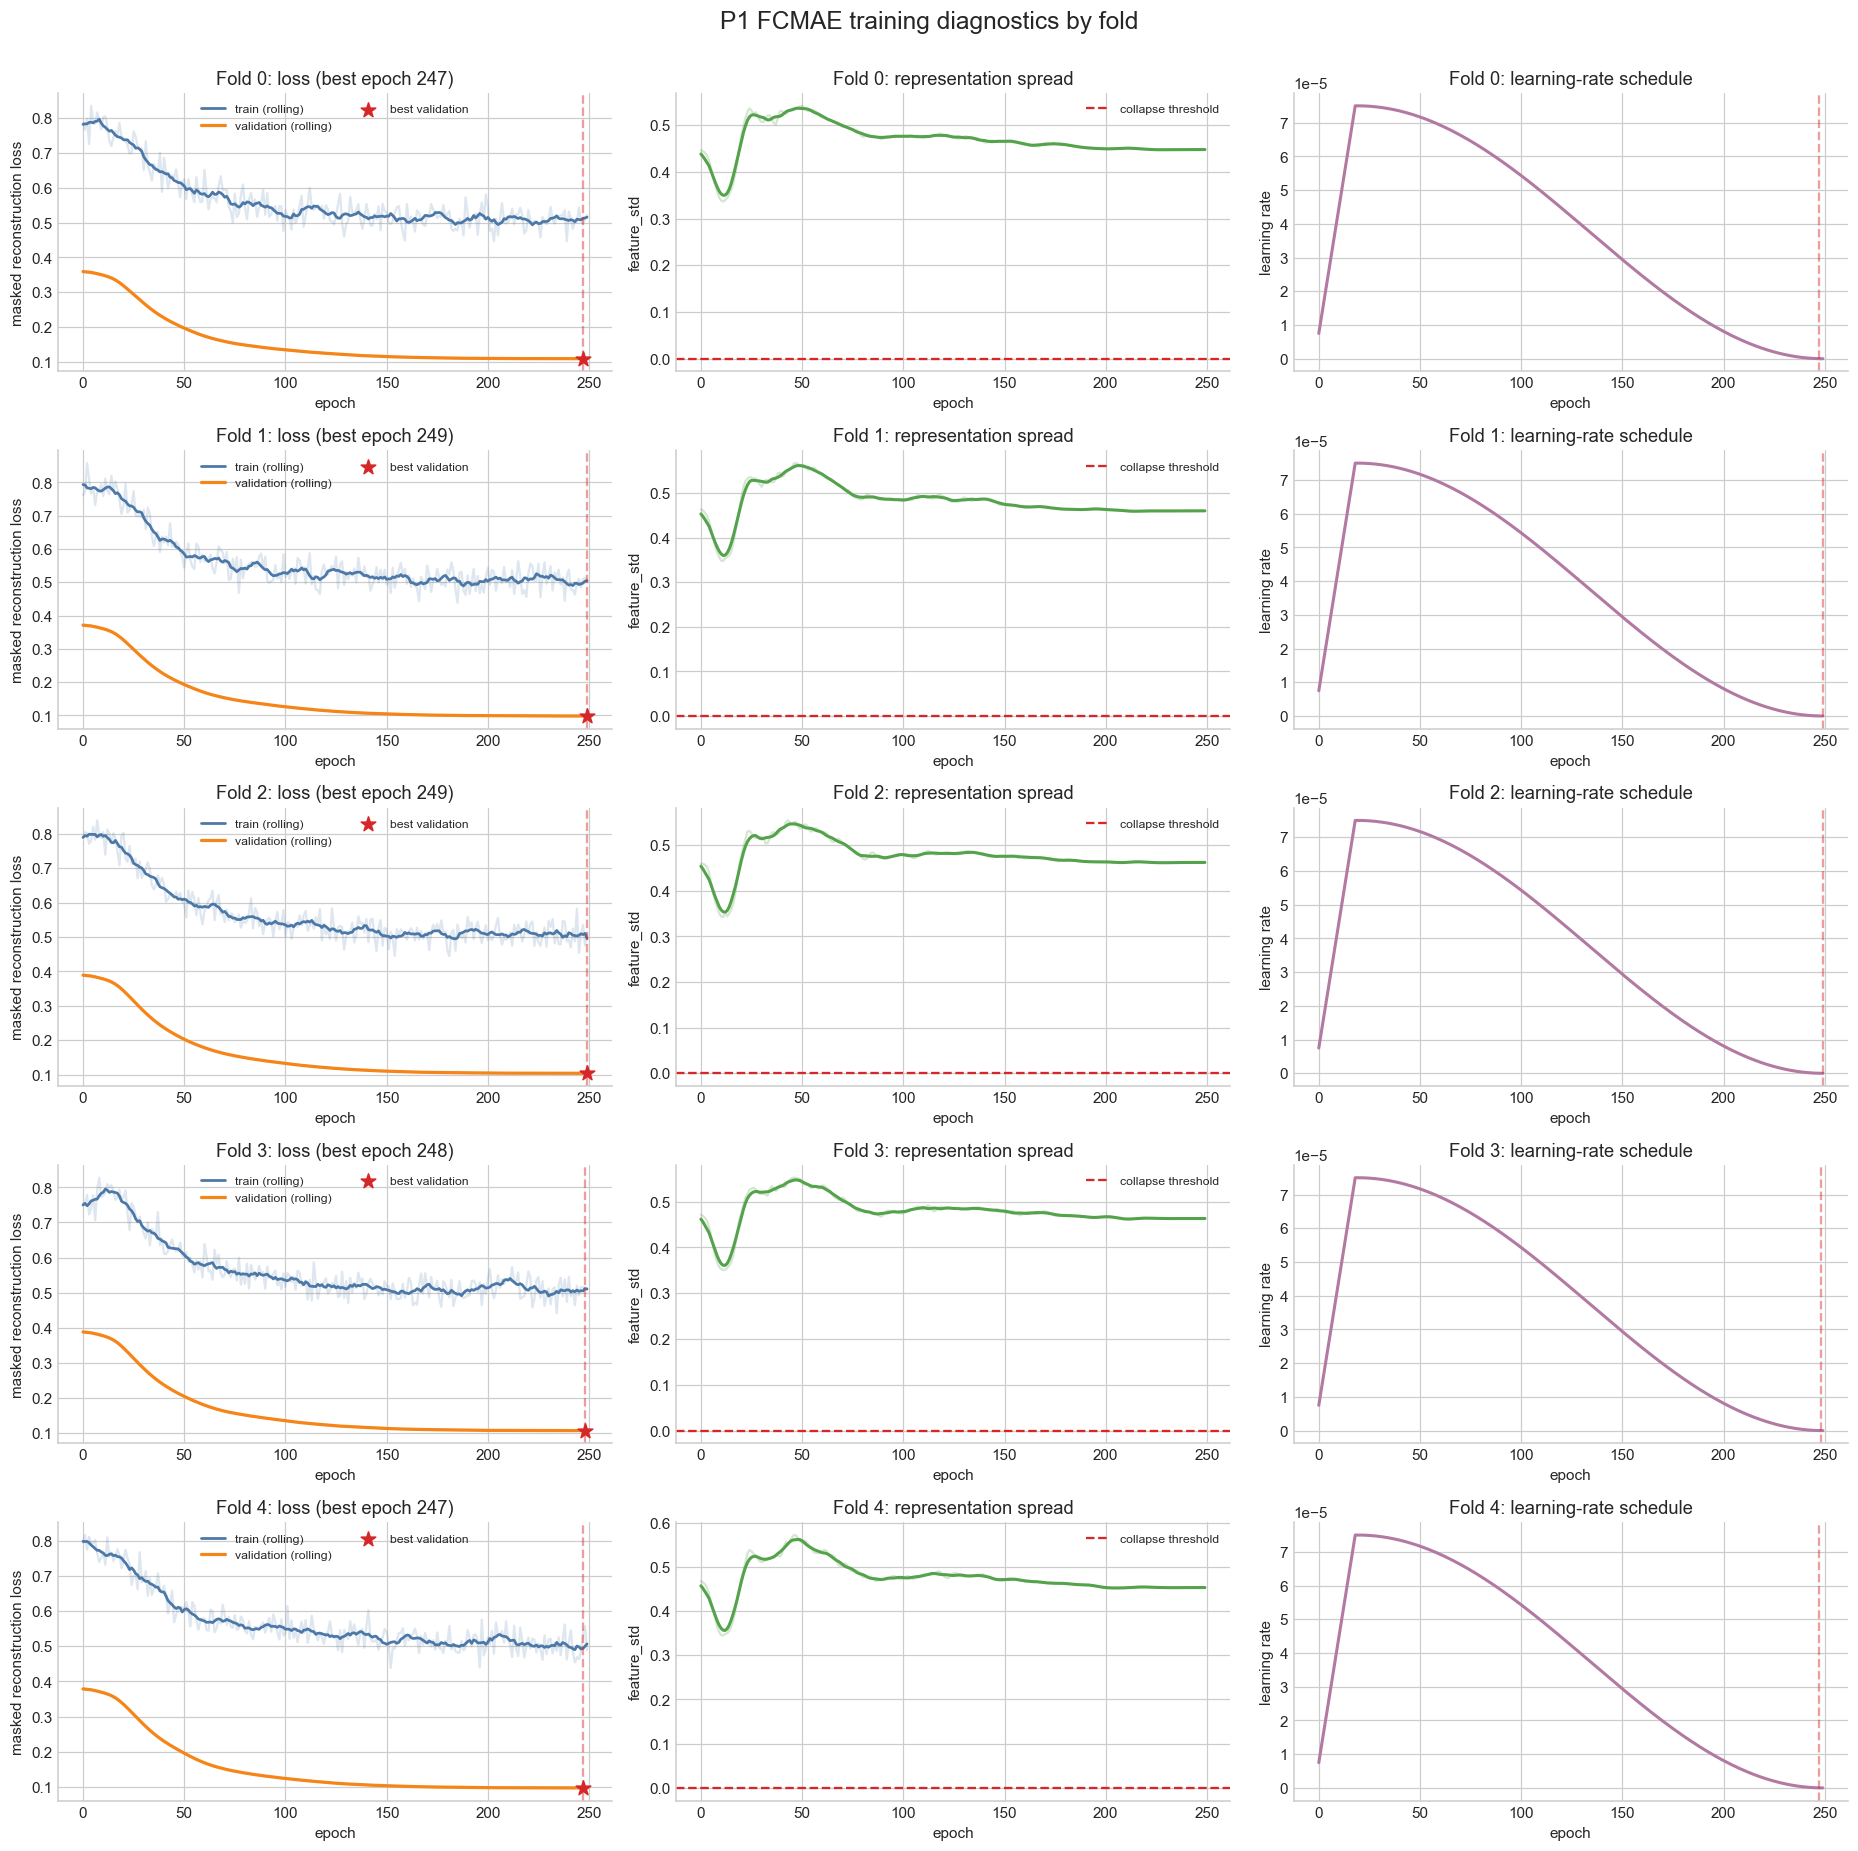

In [14]:
figure, axes = plt.subplots(len(folds), 3, figsize=(17, 3.35 * len(folds)), squeeze=False)
for row, fold in enumerate(folds):
    fold_data = history.loc[history.fold == fold].copy()
    best = fold_data.loc[fold_data.validation_loss.idxmin()]
    smooth = fold_data[["train_loss", "validation_loss", "feature_std"]].rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()

    loss_axis, feature_axis, lr_axis = axes[row]
    loss_axis.plot(fold_data.epoch, fold_data.train_loss, color="#4C78A8", alpha=0.18)
    loss_axis.plot(fold_data.epoch, fold_data.validation_loss, color="#F58518", alpha=0.22)
    loss_axis.plot(fold_data.epoch, smooth.train_loss, color="#4C78A8", linewidth=1.8, label="train (rolling)")
    loss_axis.plot(fold_data.epoch, smooth.validation_loss, color="#F58518", linewidth=2.1, label="validation (rolling)")
    loss_axis.scatter(best.epoch, best.validation_loss, color="#D62728", marker="*", s=100, zorder=5, label="best validation")
    loss_axis.axvline(best.epoch, color="#D62728", linestyle="--", alpha=0.45)
    loss_axis.set(title=f"Fold {fold}: loss (best epoch {int(best.epoch)})", xlabel="epoch", ylabel="masked reconstruction loss")
    loss_axis.legend(fontsize=8, ncol=2)

    feature_axis.plot(fold_data.epoch, fold_data.feature_std, color="#54A24B", alpha=0.25)
    feature_axis.plot(fold_data.epoch, smooth.feature_std, color="#54A24B", linewidth=2)
    feature_axis.axhline(FEATURE_STD_MIN, color="#D62728", linestyle="--", label="collapse threshold")
    feature_axis.set(title=f"Fold {fold}: representation spread", xlabel="epoch", ylabel="feature_std")
    feature_axis.legend(fontsize=8)

    lr_axis.plot(fold_data.epoch, fold_data.lr, color="#B279A2", linewidth=2)
    lr_axis.axvline(best.epoch, color="#D62728", linestyle="--", alpha=0.45)
    lr_axis.set(title=f"Fold {fold}: learning-rate schedule", xlabel="epoch", ylabel="learning rate")
    lr_axis.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))

figure.suptitle("P1 FCMAE training diagnostics by fold", fontsize=16, y=1.002)
figure.tight_layout()
plt.show()

## 3. Per-fold numerical summary

`improvement_pct` measures the decrease from epoch 0 to the best validation loss. `final_vs_best_pct` measures how far the final epoch sits above the best checkpoint; it is descriptive rather than an automatic overfitting diagnosis.

In [15]:
summary_rows = []
for fold, fold_data in history.groupby("fold", sort=True):
    fold_data = fold_data.sort_values("epoch")
    best = fold_data.loc[fold_data.validation_loss.idxmin()]
    initial = fold_data.iloc[0]
    final = fold_data.iloc[-1]
    tail_size = min(20, max(1, len(fold_data) // 4))
    tail = fold_data.tail(tail_size).validation_loss
    summary_rows.append({
        "fold": int(fold),
        "epochs": len(fold_data),
        "initial_val_loss": initial.validation_loss,
        "best_val_loss": best.validation_loss,
        "best_epoch": int(best.epoch),
        "final_val_loss": final.validation_loss,
        "improvement_pct": 100 * (initial.validation_loss - best.validation_loss) / initial.validation_loss,
        "final_vs_best_pct": 100 * (final.validation_loss - best.validation_loss) / best.validation_loss,
        "epochs_after_best": int(final.epoch - best.epoch),
        "tail_val_mean": tail.mean(),
        "tail_val_std": tail.std(ddof=0),
        "min_feature_std": fold_data.feature_std.min(),
        "feature_std_at_best": best.feature_std,
        "final_feature_std": final.feature_std,
        "peak_lr": fold_data.lr.max(),
        "peak_lr_epoch": int(fold_data.loc[fold_data.lr.idxmax(), "epoch"]),
    })

summary = pd.DataFrame(summary_rows).set_index("fold")
display(
    summary.style
    .format({
        "initial_val_loss": "{:.5f}", "best_val_loss": "{:.5f}", "final_val_loss": "{:.5f}",
        "improvement_pct": "{:.1f}%", "final_vs_best_pct": "{:.1f}%",
        "tail_val_mean": "{:.5f}", "tail_val_std": "{:.5f}",
        "min_feature_std": "{:.4f}", "feature_std_at_best": "{:.4f}", "final_feature_std": "{:.4f}", "peak_lr": "{:.2e}",
    })
    .background_gradient(subset=["best_val_loss"], cmap="RdYlGn_r")
    .background_gradient(subset=["improvement_pct"], cmap="YlGn")
)

,epochs,initial_val_loss,best_val_loss,best_epoch,final_val_loss,improvement_pct,final_vs_best_pct,epochs_after_best,tail_val_mean,tail_val_std,min_feature_std,feature_std_at_best,final_feature_std,peak_lr,peak_lr_epoch
fold,,,,,,,,,,,,,,,
0,250,0.36083,0.10966,247,0.10966,69.6%,0.0%,2,0.10967,0.00002,0.3362,0.4475,0.4476,7.50e-05,18
1,250,0.37259,0.09814,249,0.09814,73.7%,0.0%,0,0.09814,0.00001,0.3476,0.4599,0.4599,7.50e-05,18
2,250,0.39068,0.10381,249,0.10381,73.4%,0.0%,0,0.10383,0.00002,0.3427,0.4623,0.4623,7.50e-05,18
3,250,0.38948,0.10680,248,0.10680,72.6%,0.0%,1,0.10683,0.00003,0.3505,0.4630,0.4630,7.50e-05,18
4,250,0.38024,0.09762,247,0.09762,74.3%,0.0%,2,0.09763,0.00001,0.3448,0.4530,0.4530,7.50e-05,18


### Final feature standard deviation by fold

This view compares representation spread at the final recorded epoch. The y-axis starts at zero to preserve the magnitude of the values. The structural collapse threshold is `1e-6`, far below the plotted values, so it is reported in the caption instead of forcing an unreadable axis scale.

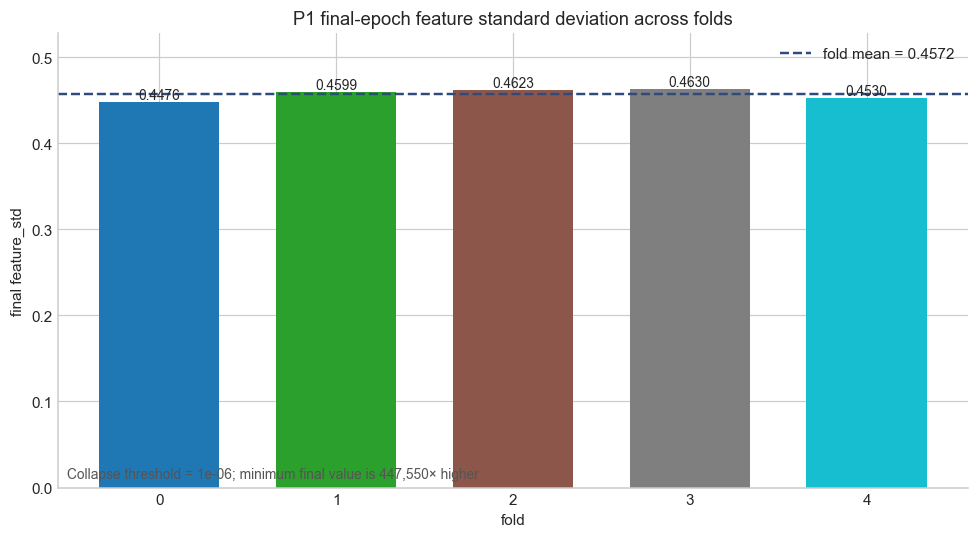

In [16]:
final_feature_std = summary.loc[folds, "final_feature_std"]
final_feature_mean = final_feature_std.mean()

figure, axis = plt.subplots(figsize=(9, 5))
bars = axis.bar([str(fold) for fold in folds], final_feature_std, color=[colors[fold] for fold in folds], width=0.68)
axis.axhline(final_feature_mean, color="#2F4B7C", linestyle="--", linewidth=1.6, label=f"fold mean = {final_feature_mean:.4f}")
for bar, value in zip(bars, final_feature_std):
    axis.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.4f}", ha="center", va="bottom", fontsize=9)
axis.set(
    title="P1 final-epoch feature standard deviation across folds",
    xlabel="fold", ylabel="final feature_std",
    ylim=(0, final_feature_std.max() * 1.14),
)
axis.legend()
axis.text(
    0.01, 0.02, f"Collapse threshold = {FEATURE_STD_MIN:.0e}; minimum final value is {final_feature_std.min() / FEATURE_STD_MIN:,.0f}× higher",
    transform=axis.transAxes, fontsize=9, color="#555555",
)
figure.tight_layout()
plt.show()

## 4. Cross-fold summary visual

This is the compact figure to use when explaining P1 training as a whole. It answers: Did all folds converge similarly? How variable were they? How much did each improve? When did each best checkpoint occur?

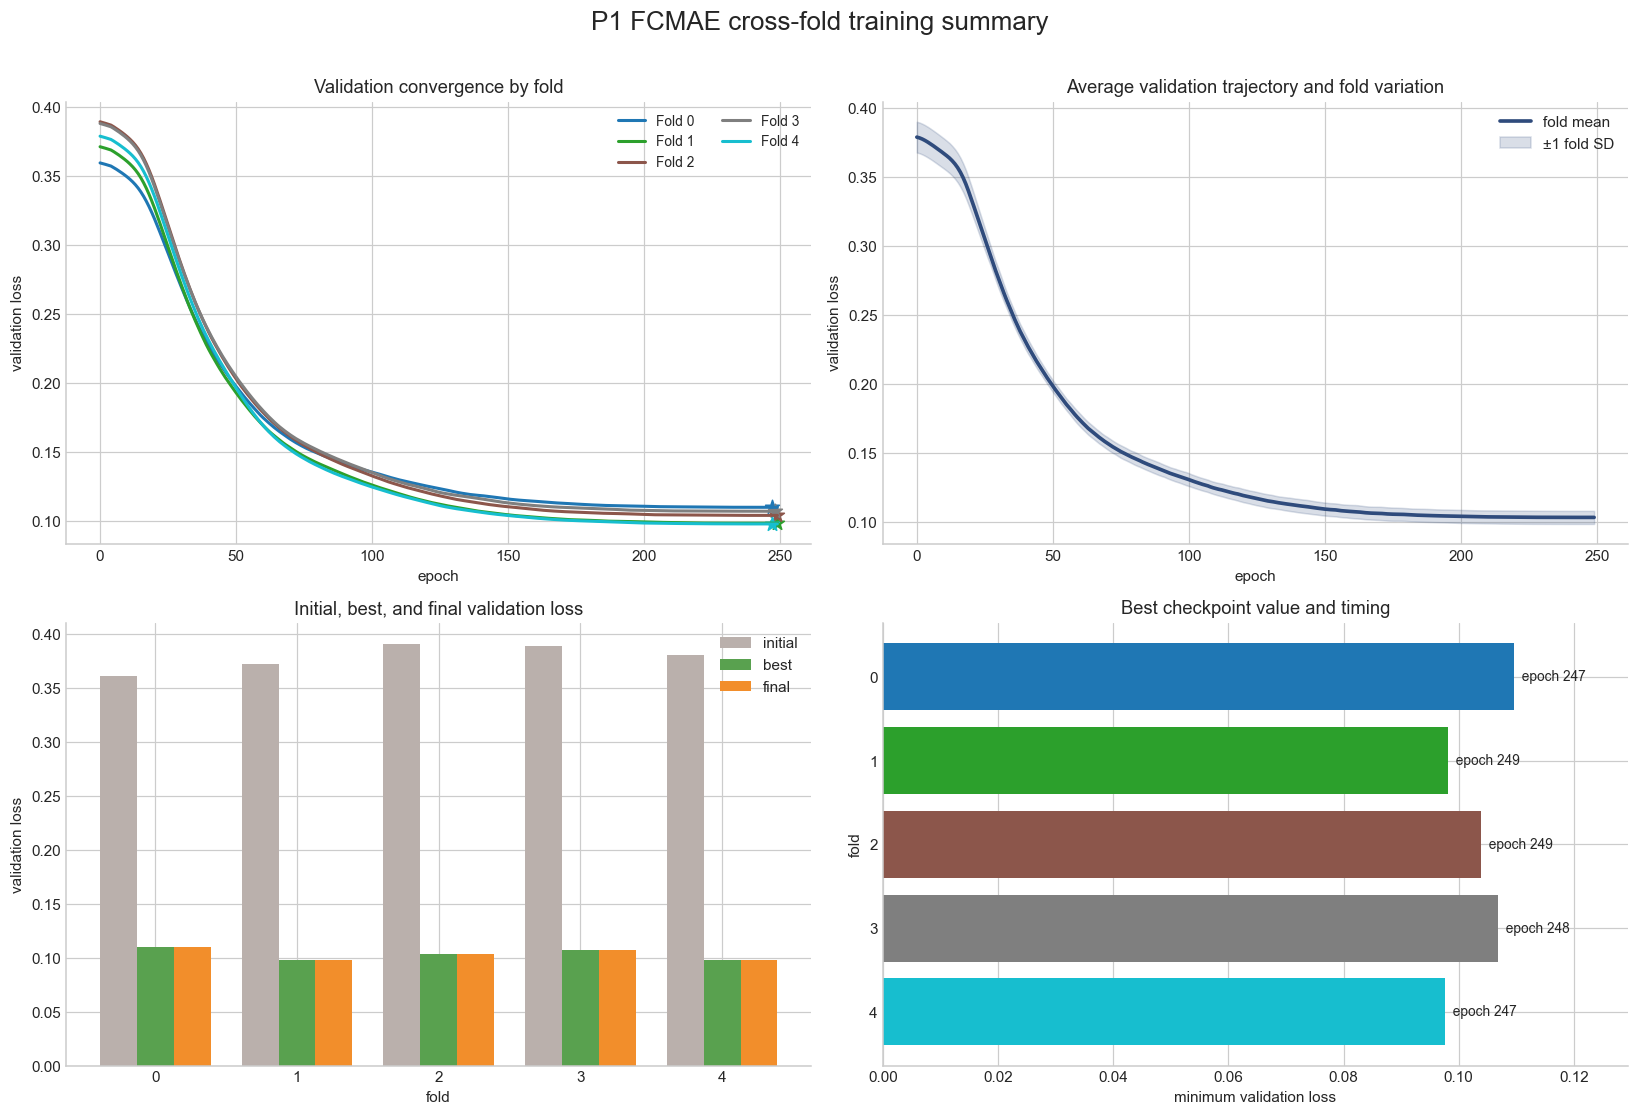

In [17]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
trajectory_axis, aggregate_axis, improvement_axis, checkpoint_axis = axes.ravel()

validation_wide = history.pivot(index="epoch", columns="fold", values="validation_loss").sort_index()
validation_smooth = validation_wide.rolling(ROLLING_WINDOW, center=True, min_periods=1).mean()
for fold in folds:
    trajectory_axis.plot(validation_smooth.index, validation_smooth[fold], color=colors[fold], linewidth=2, label=f"Fold {fold}")
    best_epoch = summary.loc[fold, "best_epoch"]
    trajectory_axis.scatter(best_epoch, history.query("fold == @fold and epoch == @best_epoch").validation_loss.iloc[0], color=colors[fold], marker="*", s=90)
trajectory_axis.set(title="Validation convergence by fold", xlabel="epoch", ylabel="validation loss")
trajectory_axis.legend(ncol=2, fontsize=9)

mean_curve = validation_wide.mean(axis=1)
std_curve = validation_wide.std(axis=1, ddof=0)
aggregate_axis.plot(mean_curve.index, mean_curve, color="#2F4B7C", linewidth=2.4, label="fold mean")
aggregate_axis.fill_between(mean_curve.index, mean_curve - std_curve, mean_curve + std_curve, color="#2F4B7C", alpha=0.18, label="±1 fold SD")
aggregate_axis.set(title="Average validation trajectory and fold variation", xlabel="epoch", ylabel="validation loss")
aggregate_axis.legend()

x = np.arange(len(folds))
width = 0.26
improvement_axis.bar(x - width, summary.loc[folds, "initial_val_loss"], width, label="initial", color="#BAB0AC")
improvement_axis.bar(x, summary.loc[folds, "best_val_loss"], width, label="best", color="#59A14F")
improvement_axis.bar(x + width, summary.loc[folds, "final_val_loss"], width, label="final", color="#F28E2B")
improvement_axis.set(title="Initial, best, and final validation loss", xlabel="fold", ylabel="validation loss", xticks=x, xticklabels=folds)
improvement_axis.legend()

bars = checkpoint_axis.barh([str(fold) for fold in folds], summary.loc[folds, "best_val_loss"], color=[colors[fold] for fold in folds])
for bar, fold in zip(bars, folds):
    checkpoint_axis.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f"  epoch {summary.loc[fold, 'best_epoch']:.0f}", va="center", fontsize=9)
checkpoint_axis.invert_yaxis()
checkpoint_axis.set(title="Best checkpoint value and timing", xlabel="minimum validation loss", ylabel="fold")
checkpoint_axis.set_xlim(right=summary.best_val_loss.max() * 1.18)

figure.suptitle("P1 FCMAE cross-fold training summary", fontsize=17, y=1.01)
figure.tight_layout()
plt.show()

## 5. Automated reading of the run history

These statements are descriptive checks from the CSVs. They do not replace downstream feature audit or reconstruction evaluation.

In [18]:
best_fold = int(summary.best_val_loss.idxmin())
best_loss_mean = summary.best_val_loss.mean()
best_loss_sd = summary.best_val_loss.std(ddof=0)
best_loss_cv = best_loss_sd / best_loss_mean
feature_margin = summary.min_feature_std.min() / FEATURE_STD_MIN
late_best = summary.index[summary.epochs_after_best < 30].tolist()
not_late_best = summary.index[summary.epochs_after_best >= 30].tolist()

lines = [
    "### What these runs show",
    f"- All {len(folds)} folds improved over their epoch-0 validation loss; improvement ranged from **{summary.improvement_pct.min():.1f}% to {summary.improvement_pct.max():.1f}%**.",
    f"- Best validation loss averaged **{best_loss_mean:.5f} ± {best_loss_sd:.5f}** across folds (coefficient of variation **{best_loss_cv:.1%}**).",
    f"- Fold **{best_fold}** reached the lowest individual validation loss (**{summary.loc[best_fold, 'best_val_loss']:.5f}** at epoch **{summary.loc[best_fold, 'best_epoch']:.0f}**). This is a fold-specific result, not a claim that one fold is intrinsically better.",
    f"- Best checkpoints occurred between epochs **{summary.best_epoch.min():.0f} and {summary.best_epoch.max():.0f}**.",
    f"- The minimum observed feature standard deviation was **{summary.min_feature_std.min():.4f}**, about **{feature_margin:,.0f}×** the collapse threshold; no recorded fold crossed the collapse guardrail.",
]
if not_late_best:
    lines.append(f"- Folds **{not_late_best}** ran at least 30 epochs after their best checkpoint. Use the best checkpoint rather than assuming the final epoch is optimal.")
if late_best:
    lines.append(f"- Folds **{late_best}** placed their best checkpoint within the final 30 epochs, so their late-stage trajectory deserves close visual inspection.")
lines.extend([
    "",
    "### Interpretation limits",
    "- These histories establish optimization behavior and representation non-collapse only. They do not establish anatomical usefulness; that requires the independent feature audit and downstream reconstruction results.",
    "- Do not compare train and validation loss as if they were measured under identical inputs: stochastic masks and training augmentation can make training loss noisier or higher.",
])
display(Markdown("\n".join(lines)))

### What these runs show
- All 5 folds improved over their epoch-0 validation loss; improvement ranged from **69.6% to 74.3%**.
- Best validation loss averaged **0.10321 ± 0.00473** across folds (coefficient of variation **4.6%**).
- Fold **4** reached the lowest individual validation loss (**0.09762** at epoch **247**). This is a fold-specific result, not a claim that one fold is intrinsically better.
- Best checkpoints occurred between epochs **247 and 249**.
- The minimum observed feature standard deviation was **0.3362**, about **336,207×** the collapse threshold; no recorded fold crossed the collapse guardrail.
- Folds **[0, 1, 2, 3, 4]** placed their best checkpoint within the final 30 epochs, so their late-stage trajectory deserves close visual inspection.

### Interpretation limits
- These histories establish optimization behavior and representation non-collapse only. They do not establish anatomical usefulness; that requires the independent feature audit and downstream reconstruction results.
- Do not compare train and validation loss as if they were measured under identical inputs: stochastic masks and training augmentation can make training loss noisier or higher.

## 6. Independent frozen-encoder feature audit

Training loss shows that FCMAE optimized successfully, but it does not establish that the learned features retain anatomy useful for reconstruction. This section reads the completed audit summaries from `HPC/HPC_results/feature_audit` and compares **pinned initialization → P1** across the same folds. P2 is intentionally excluded so that the visual isolates what P1 changed.

The four panels answer different questions:

- **Local probe Dice:** can a frozen L1 feature map expose bone location through only a disposable 1×1 linear probe?
- **Cross-view MRR:** can global AP/LAT descriptors retrieve the matching knee? Higher is better.
- **Paired cosine margin:** is the matching AP/LAT pair more similar than non-matching pairs? Positive is required.
- **Effective rank:** does variation span multiple feature directions rather than collapse into a near-constant representation?

In [19]:
import json

AUDIT_ROOT = PROJECT_ROOT / "HPC" / "HPC_results" / "feature_audit"
AUDIT_STAGES = ("pinned_init", "p1")
AUDIT_SCHEMA = "encoder_feature_audit_v1"
STAGE_LABELS = {"pinned_init": "Pinned init", "p1": "P1"}
STAGE_COLORS = {"pinned_init": "#9C9C9C", "p1": "#4C78A8"}

audit_rows = []
for fold in folds:
    for stage in AUDIT_STAGES:
        path = AUDIT_ROOT / f"fold{fold}" / stage / "feature_audit_summary.json"
        if not path.is_file():
            raise FileNotFoundError(f"Missing audit summary: {path}")
        payload = json.loads(path.read_text(encoding="utf-8"))
        if payload.get("schema_version") != AUDIT_SCHEMA or int(payload.get("fold", -1)) != int(fold):
            raise ValueError(f"Audit schema/fold mismatch: {path}")
        if payload.get("structural_status") != "PASS":
            raise RuntimeError(f"Fold {fold} {stage} failed the structural audit")
        if payload.get("test_paths_opened") is not False or payload.get("encoder_unchanged") is not True:
            raise RuntimeError(f"Fold {fold} {stage} violates the frozen/test-sealed audit contract")

        probes = payload["local"]["probes"]
        best_probe_level = max(probes, key=lambda level: probes[level]["validation_macro_dice"])
        row = {
            "fold": int(fold), "stage": stage, "stage_label": STAGE_LABELS[stage],
            "structural_status": payload["structural_status"],
            "quality_status": payload["quality_status"],
            "local_status": payload["local"]["status"],
            "global_status": payload["global"]["status"],
            "warnings": ", ".join(payload.get("warnings", [])) or "none",
            "best_probe_level": best_probe_level,
            "best_local_dice": probes[best_probe_level]["validation_macro_dice"],
            "atlas_dice": probes[best_probe_level]["atlas_macro_dice"],
            "local_control_delta": probes[best_probe_level]["control_delta"],
            "local_control_ci95_low": probes[best_probe_level]["control_delta_ci95_low"],
            "mrr": payload["global"]["mrr"],
            "recall_at_1": payload["global"]["recall_at_1"],
            "recall_at_5": payload["global"]["recall_at_5"],
            "paired_cosine_margin": payload["global"]["paired_cosine_margin"],
            "paired_margin_ci95_low": payload["global"]["paired_margin_ci95_low"],
            "permutation_p_value": payload["global"]["permutation_p_value"],
        }
        for level in ("L0", "L1", "L2", "L3"):
            statistics = payload["feature_statistics"][level]
            row[f"effective_rank_{level}"] = statistics["effective_rank"]
            row[f"largest_covariance_fraction_{level}"] = statistics["largest_covariance_fraction"]
            row[f"aggregate_std_{level}"] = statistics["aggregate_std"]
        audit_rows.append(row)

audit = pd.DataFrame(audit_rows)
audit["stage_order"] = audit.stage.map({stage: order for order, stage in enumerate(AUDIT_STAGES)})
audit = audit.sort_values(["fold", "stage_order"]).drop(columns="stage_order").reset_index(drop=True)
print(f"Loaded {len(audit)} audit summaries from: {AUDIT_ROOT}")
print(f"Covered folds: {sorted(audit.fold.unique())} | stages: {list(AUDIT_STAGES)}")

Loaded 10 audit summaries from: C:\Users\Chan Zheng Shao\OneDrive\Desktop\Github Repo\TestProject\TestProject\HPC\HPC_results\feature_audit
Covered folds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | stages: ['pinned_init', 'p1']


In [20]:
audit_status = audit[["fold", "stage_label", "structural_status", "quality_status", "local_status", "global_status", "warnings"]]
display(audit_status)

metric_names = ["best_local_dice", "mrr", "recall_at_1", "paired_cosine_margin"]
audit_comparison = audit.pivot(index="fold", columns="stage", values=metric_names)
audit_delta = pd.DataFrame(index=folds)
for metric in metric_names:
    audit_delta[f"{metric}_pinned"] = audit_comparison[(metric, "pinned_init")]
    audit_delta[f"{metric}_p1"] = audit_comparison[(metric, "p1")]
    audit_delta[f"{metric}_change"] = audit_delta[f"{metric}_p1"] - audit_delta[f"{metric}_pinned"]
audit_delta.index.name = "fold"
change_columns = [column for column in audit_delta.columns if column.endswith("_change")]
comparison_style = audit_delta.style.format({column: "{:.4f}" for column in audit_delta.columns})
for column in change_columns:
    limit = audit_delta[column].abs().max()
    comparison_style = comparison_style.background_gradient(subset=[column], cmap="RdYlGn", vmin=-limit, vmax=limit)
display(comparison_style)

,fold,stage_label,structural_status,quality_status,local_status,global_status,warnings
0,0,Pinned init,PASS,PASS,PASS,PASS,none
1,0,P1,PASS,WARN,PASS,PASS,reference_comparison_incomplete
2,1,Pinned init,PASS,PASS,PASS,PASS,none
3,1,P1,PASS,WARN,PASS,PASS,reference_comparison_incomplete
4,2,Pinned init,PASS,WARN,PASS,WARN,global_feature_evidence_below_threshold
5,2,P1,PASS,WARN,PASS,WARN,"reference_comparison_incomplete, global_featur..."
6,3,Pinned init,PASS,WARN,PASS,WARN,global_feature_evidence_below_threshold
7,3,P1,PASS,WARN,PASS,PASS,reference_comparison_incomplete
8,4,Pinned init,PASS,PASS,PASS,PASS,none
9,4,P1,PASS,WARN,PASS,PASS,reference_comparison_incomplete


,best_local_dice_pinned,best_local_dice_p1,best_local_dice_change,mrr_pinned,mrr_p1,mrr_change,recall_at_1_pinned,recall_at_1_p1,recall_at_1_change,paired_cosine_margin_pinned,paired_cosine_margin_p1,paired_cosine_margin_change
fold,,,,,,,,,,,,
0,0.6267,0.6377,0.0111,0.4678,0.5156,0.0477,0.2500,0.3214,0.0714,0.0010,0.0026,0.0016
1,0.6661,0.6576,-0.0085,0.3625,0.3660,0.0035,0.1786,0.1429,-0.0357,0.0006,0.0170,0.0164
2,0.6561,0.6448,-0.0113,0.2705,0.2532,-0.0173,0.0714,0.0714,0.0000,0.0003,0.0005,0.0002
3,0.6468,0.6491,0.0023,0.3145,0.3642,0.0497,0.1429,0.1786,0.0357,0.0005,0.0016,0.0011
4,0.6677,0.6552,-0.0125,0.3000,0.3620,0.0620,0.1000,0.1667,0.0667,0.0005,0.0021,0.0016


### Pinned initialization versus P1

Each connected pair is the same fold before and after P1. This paired presentation prevents differences in fold difficulty from being mistaken for a training effect. The atlas line in the local panel is a dataset-average anatomical control, not another learned model.

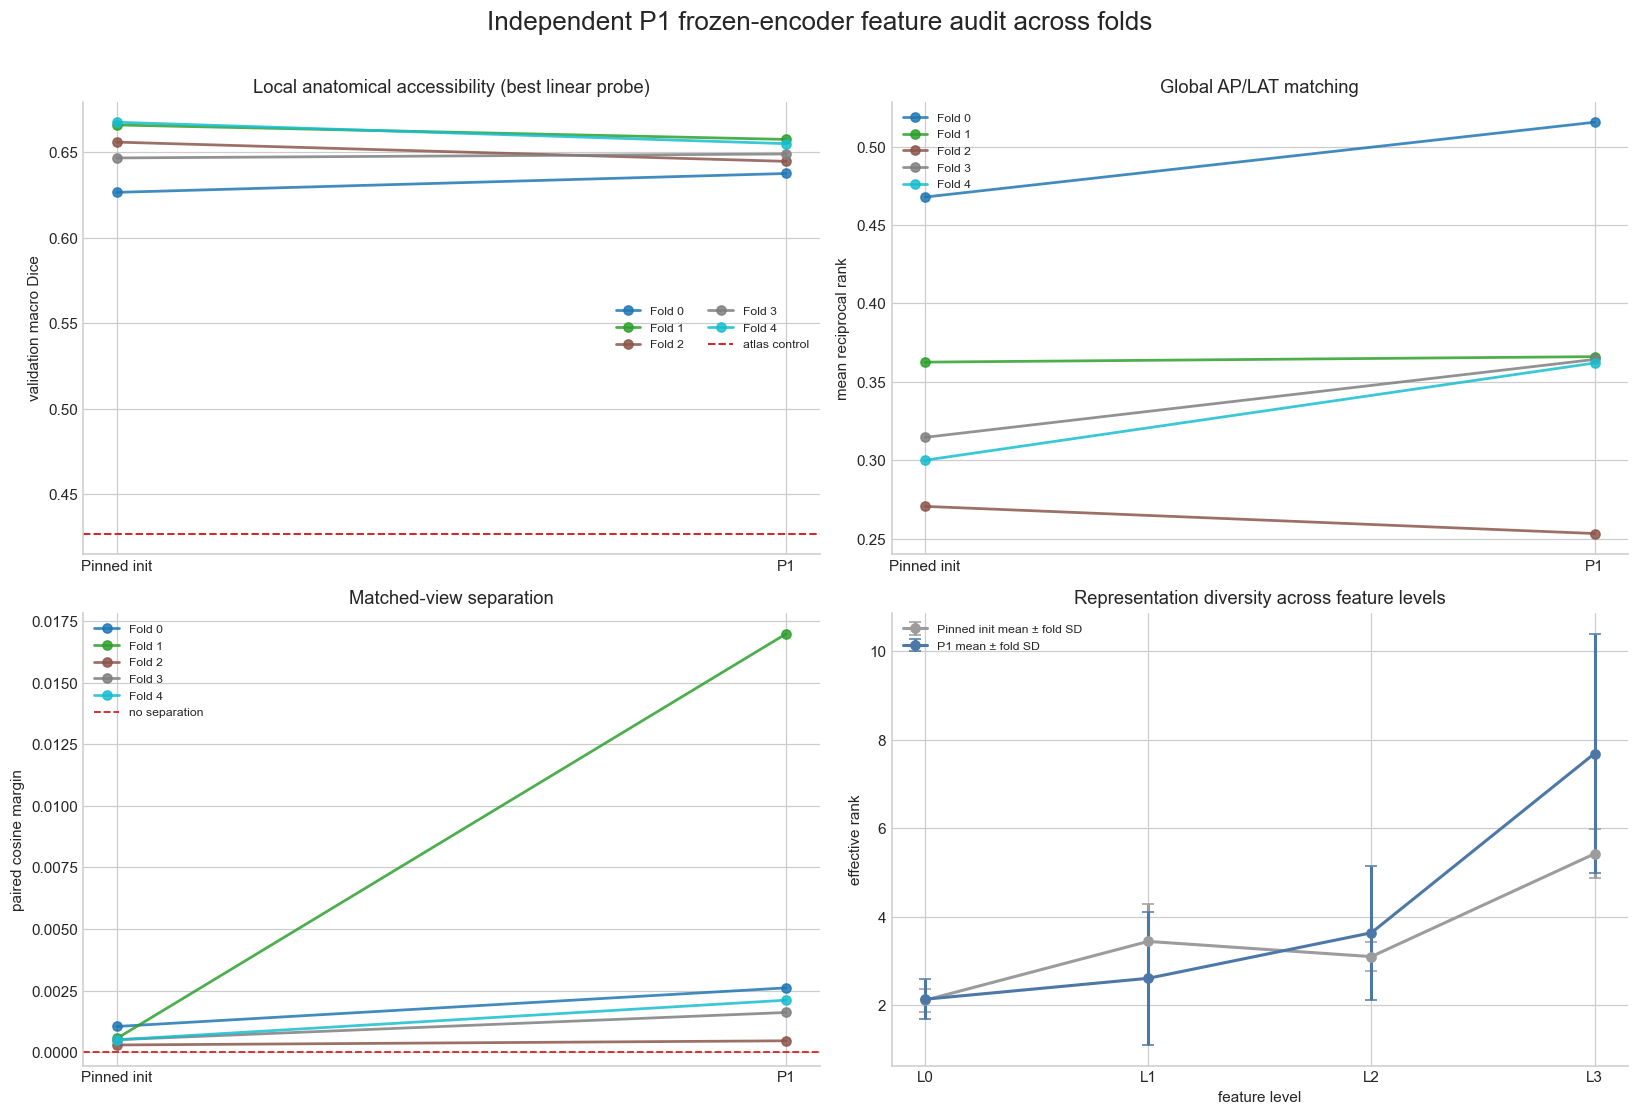

In [21]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))
local_axis, retrieval_axis, margin_axis, rank_axis = axes.ravel()

def paired_stage_plot(axis, metric, title, ylabel, baseline=None):
    for fold in folds:
        values = [audit.query("fold == @fold and stage == @stage")[metric].iloc[0] for stage in AUDIT_STAGES]
        axis.plot([0, 1], values, color=colors[fold], marker="o", linewidth=1.8, alpha=0.85, label=f"Fold {fold}")
    if baseline is not None:
        axis.axhline(baseline, color="#D62728", linestyle="--", linewidth=1.3, label="atlas control")
    axis.set(title=title, ylabel=ylabel, xticks=[0, 1], xticklabels=[STAGE_LABELS[stage] for stage in AUDIT_STAGES])

atlas_control = audit.query("stage == 'p1'").atlas_dice.mean()
paired_stage_plot(local_axis, "best_local_dice", "Local anatomical accessibility (best linear probe)", "validation macro Dice", baseline=atlas_control)
local_axis.legend(ncol=2, fontsize=8)

paired_stage_plot(retrieval_axis, "mrr", "Global AP/LAT matching", "mean reciprocal rank")
retrieval_axis.legend(fontsize=8)

paired_stage_plot(margin_axis, "paired_cosine_margin", "Matched-view separation", "paired cosine margin")
margin_axis.axhline(0, color="#D62728", linestyle="--", linewidth=1.2, label="no separation")
margin_axis.legend(fontsize=8)

levels = ["L0", "L1", "L2", "L3"]
level_x = np.arange(len(levels))
for stage in AUDIT_STAGES:
    stage_data = audit.query("stage == @stage")
    means = np.array([stage_data[f"effective_rank_{level}"].mean() for level in levels])
    deviations = np.array([stage_data[f"effective_rank_{level}"].std(ddof=0) for level in levels])
    rank_axis.errorbar(level_x, means, yerr=deviations, marker="o", capsize=4, linewidth=2, color=STAGE_COLORS[stage], label=f"{STAGE_LABELS[stage]} mean ± fold SD")
rank_axis.set(title="Representation diversity across feature levels", xlabel="feature level", ylabel="effective rank", xticks=level_x, xticklabels=levels)
rank_axis.legend(fontsize=8)

figure.suptitle("Independent P1 frozen-encoder feature audit across folds", fontsize=17, y=1.01)
figure.tight_layout()
plt.show()

### Automated feature-audit summary

The statements below distinguish structural validity from representation quality. A structural failure would invalidate the audit; a quality WARN is evidence to report and investigate, but it is not automatically a pipeline failure.

In [22]:
p1_audit = audit.query("stage == 'p1'").set_index("fold")
local_improved = audit_delta.index[audit_delta.best_local_dice_change > 0].tolist()
mrr_improved = audit_delta.index[audit_delta.mrr_change > 0].tolist()
margin_improved = audit_delta.index[audit_delta.paired_cosine_margin_change > 0].tolist()
substantive_warnings = {
    int(row.fold): [warning for warning in row.warnings.split(", ") if warning not in {"none", "reference_comparison_incomplete"}]
    for row in audit.query("stage == 'p1'").itertuples()
}
substantive_warnings = {fold: warnings for fold, warnings in substantive_warnings.items() if warnings}
pinned_l3_rank = audit.query("stage == 'pinned_init'").effective_rank_L3.mean()

audit_lines = [
    "### What the independent audit adds",
    f"- **Structural validity:** all {len(folds)} P1 audits passed, the encoder remained unchanged during evaluation, and no test paths were opened.",
    f"- **Local anatomy:** P1 improved best linear-probe Dice in {len(local_improved)}/{len(folds)} folds ({local_improved}); the mean paired change was **{audit_delta.best_local_dice_change.mean():+.4f}**. Every P1 fold remained above its atlas control.",
    f"- **Cross-view retrieval:** P1 improved MRR in {len(mrr_improved)}/{len(folds)} folds ({mrr_improved}); the mean paired change was **{audit_delta.mrr_change.mean():+.4f}**.",
    f"- **Matched-view separation:** the cosine margin stayed positive in every P1 fold and increased in {len(margin_improved)}/{len(folds)} folds ({margin_improved}).",
    f"- **Representation diversity:** mean L3 effective rank changed from **{pinned_l3_rank:.2f}** to **{p1_audit.effective_rank_L3.mean():.2f}** after P1; all recorded feature scales remained finite and non-zero.",
]
if substantive_warnings:
    audit_lines.append(f"- **Remaining quality warning:** {substantive_warnings}. These are representation-quality findings, not structural audit failures.")
audit_lines.extend([
    "",
    "### Overall P1 interpretation",
    "- P1 optimization converged consistently and produced non-collapsed features, but its downstream effect is mixed rather than uniformly better: global cross-view evidence generally improved, while local probe Dice improved in only part of the folds.",
    "- All copied P1 summaries contain `reference_comparison_incomplete` because their original sibling lookup was not preserved in the HPC-results layout. This notebook resolves that presentation issue by loading the pinned-init and P1 summaries directly and pairing them by fold.",
    "- Feature-audit evidence supports proceeding to downstream evaluation, while keeping fold-specific variation visible; it does not prove 3D reconstruction quality by itself.",
])
display(Markdown("\n".join(audit_lines)))

### What the independent audit adds
- **Structural validity:** all 5 P1 audits passed, the encoder remained unchanged during evaluation, and no test paths were opened.
- **Local anatomy:** P1 improved best linear-probe Dice in 2/5 folds ([0, 3]); the mean paired change was **-0.0038**. Every P1 fold remained above its atlas control.
- **Cross-view retrieval:** P1 improved MRR in 4/5 folds ([0, 1, 3, 4]); the mean paired change was **+0.0291**.
- **Matched-view separation:** the cosine margin stayed positive in every P1 fold and increased in 5/5 folds ([0, 1, 2, 3, 4]).
- **Representation diversity:** mean L3 effective rank changed from **5.42** to **7.69** after P1; all recorded feature scales remained finite and non-zero.
- **Remaining quality warning:** {2: ['global_feature_evidence_below_threshold']}. These are representation-quality findings, not structural audit failures.

### Overall P1 interpretation
- P1 optimization converged consistently and produced non-collapsed features, but its downstream effect is mixed rather than uniformly better: global cross-view evidence generally improved, while local probe Dice improved in only part of the folds.
- All copied P1 summaries contain `reference_comparison_incomplete` because their original sibling lookup was not preserved in the HPC-results layout. This notebook resolves that presentation issue by loading the pinned-init and P1 summaries directly and pairing them by fold.
- Feature-audit evidence supports proceeding to downstream evaluation, while keeping fold-specific variation visible; it does not prove 3D reconstruction quality by itself.